In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Superstore_raw.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.columns=df.columns.str.replace(' ','_')

In [6]:
df['Order_Date']=pd.to_datetime(df['Order_Date'])

In [7]:
df['Ship_Date']=pd.to_datetime(df['Ship_Date'])

In [8]:
df['Ship_Mode'].value_counts(normalize=True)*100

Ship_Mode
Standard Class    59.715829
Second Class      19.461677
First Class       15.389234
Same Day           5.433260
Name: proportion, dtype: float64

In [9]:
df['Category'].value_counts(normalize=True)*100

Category
Office Supplies    60.296178
Furniture          21.222734
Technology         18.481089
Name: proportion, dtype: float64

In [10]:
df['Segment'].value_counts(normalize=True)*100

Segment
Consumer       51.941165
Corporate      30.218131
Home Office    17.840704
Name: proportion, dtype: float64

### Feature Engineering

In [11]:
df['Profit_margin'] = df['Profit'] / df['Sales']

In [12]:
df[['Profit_margin','Profit','Sales']]

,Profit_margin,Profit,Sales
0,0.1600,41.9136,261.9600
1,0.3000,219.5820,731.9400
2,0.4700,6.8714,14.6200
3,-0.4000,-383.0310,957.5775
4,0.1125,2.5164,22.3680
...,...,...,...
9989,0.1625,4.1028,25.2480
9990,0.1700,15.6332,91.9600
9991,0.0750,19.3932,258.5760
9992,0.4500,13.3200,29.6000


In [13]:
df['Yearr'] = df['Order_Date']
df['Yearr']

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Yearr, Length: 9994, dtype: datetime64[ns]

In [14]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Quarter'] = df['Order_Date'].dt.quarter
df['Weekday'] = df['Order_Date'].dt.day_name()

In [15]:
df[['Year','Order_Date','Month','Quarter','Weekday']]

,Year,Order_Date,Month,Quarter,Weekday
0,2016,2016-11-08,11,4,Tuesday
1,2016,2016-11-08,11,4,Tuesday
2,2016,2016-06-12,6,2,Sunday
3,2015,2015-10-11,10,4,Sunday
4,2015,2015-10-11,10,4,Sunday
...,...,...,...,...,...
9989,2014,2014-01-21,1,1,Tuesday
9990,2017,2017-02-26,2,1,Sunday
9991,2017,2017-02-26,2,1,Sunday
9992,2017,2017-02-26,2,1,Sunday


In [16]:
df['Delivery_dayss'] = (df['Ship_Date'] - df['Order_Date'])

In [17]:
df['Delivery_dayss']

0      3 days
1      3 days
2      4 days
3      7 days
4      7 days
        ...  
9989   2 days
9990   5 days
9991   5 days
9992   5 days
9993   5 days
Name: Delivery_dayss, Length: 9994, dtype: timedelta64[ns]

In [18]:
df['Delivery_days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

In [19]:
df['Delivery_status'] = df['Delivery_days'].apply(lambda x: 'Late' if x > 3 else 'On-Time')

In [20]:
df[['Row_ID','Delivery_status','Delivery_days']]

,Row_ID,Delivery_status,Delivery_days
0,1,On-Time,3
1,2,On-Time,3
2,3,Late,4
3,4,Late,7
4,5,Late,7
...,...,...,...
9989,9990,On-Time,2
9990,9991,Late,5
9991,9992,Late,5
9992,9993,Late,5


In [21]:
df['Sales_per_unit'] = df['Sales'] / df['Quantity']

In [22]:
df['Discount_amount'] = df['Sales'] * df['Discount']

In [23]:
df['Final_price'] = df['Sales'] - df['Discount_amount']

In [24]:
df[['Row_ID','Sales','Quantity','Discount','Sales_per_unit','Discount_amount','Final_price']]

,Row_ID,Sales,Quantity,Discount,Sales_per_unit,Discount_amount,Final_price
0,1,261.9600,2,0.00,130.9800,0.000000,261.960000
1,2,731.9400,3,0.00,243.9800,0.000000,731.940000
2,3,14.6200,2,0.00,7.3100,0.000000,14.620000
3,4,957.5775,5,0.45,191.5155,430.909875,526.667625
4,5,22.3680,2,0.20,11.1840,4.473600,17.894400
...,...,...,...,...,...,...,...
9989,9990,25.2480,3,0.20,8.4160,5.049600,20.198400
9990,9991,91.9600,2,0.00,45.9800,0.000000,91.960000
9991,9992,258.5760,2,0.20,129.2880,51.715200,206.860800
9992,9993,29.6000,4,0.00,7.4000,0.000000,29.600000


In [25]:
customer = df.groupby('Customer_ID').agg({
    'Sales': 'sum',
    'Order_ID': 'nunique'
}).reset_index()

customer.columns = ['Customer_ID', 'Total_spent', 'Order_count']

df = df.merge(customer, on='Customer_ID', how='left')

In [26]:
df

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Quarter,Weekday,Delivery_dayss,Delivery_days,Delivery_status,Sales_per_unit,Discount_amount,Final_price,Total_spent,Order_count
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,4,Tuesday,3 days,3,On-Time,130.9800,0.000000,261.960000,1148.7800,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,4,Tuesday,3 days,3,On-Time,243.9800,0.000000,731.940000,1148.7800,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,Sunday,4 days,4,Late,7.3100,0.000000,14.620000,1119.4830,5
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,4,Sunday,7 days,7,Late,191.5155,430.909875,526.667625,2602.5755,6
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,4,Sunday,7 days,7,Late,11.1840,4.473600,17.894400,2602.5755,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,1,Tuesday,2 days,2,On-Time,8.4160,5.049600,20.198400,9133.9900,7
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,1,Sunday,5 days,5,Late,45.9800,0.000000,91.960000,4531.6460,7
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,1,Sunday,5 days,5,Late,129.2880,51.715200,206.860800,4531.6460,7
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,1,Sunday,5 days,5,Late,7.4000,0.000000,29.600000,4531.6460,7


In [27]:

df['Customer_type'] = df['Total_spent'].apply(lambda x: 'High Value' if x > 5000 else 'Low Value')


In [28]:
df['Customer_type'].value_counts(normalize=True)*100

Customer_type
Low Value     78.256954
High Value    21.743046
Name: proportion, dtype: float64

In [29]:
df['Order_size'] = df['Quantity'].apply(lambda x: 'Bulk' if x >= 5 else 'Small')

In [30]:
df['Order_size'].value_counts(normalize=True)*100

Order_size
Small    69.051431
Bulk     30.948569
Name: proportion, dtype: float64

In [31]:
df['Product_performance_flag'] = df['Profit'].apply(lambda x: 'Loss' if x < 0 else 'Profit')

In [32]:
df['Product_performance_flag'].value_counts(normalize=True)*100

Product_performance_flag
Profit    81.278767
Loss      18.721233
Name: proportion, dtype: float64

In [33]:
df['High_discount'] = df['Discount'].apply(lambda x: 'Yes' if x > 0.25 else 'No')

In [34]:
df['High_discount'].value_counts(normalize=True)*100

High_discount
No     86.061637
Yes    13.938363
Name: proportion, dtype: float64

In [35]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Profit_margin', 'Yearr', 'Year', 'Month', 'Quarter', 'Weekday',
       'Delivery_dayss', 'Delivery_days', 'Delivery_status', 'Sales_per_unit',
       'Discount_amount', 'Final_price', 'Total_spent', 'Order_count',
       'Customer_type', 'Order_size', 'Product_performance_flag',
       'High_discount'],
      dtype='object')

### Univariate 

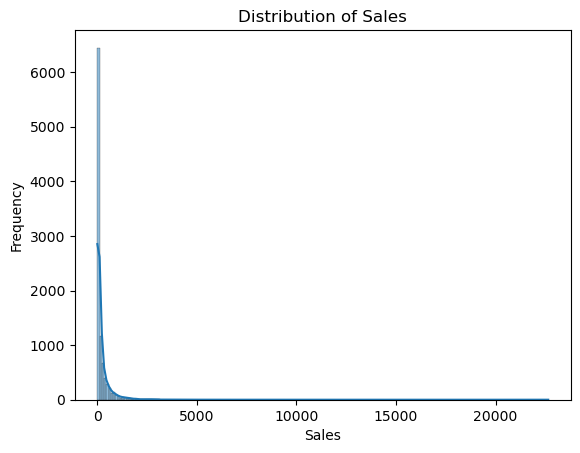

In [36]:
sns.histplot(df['Sales'], kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

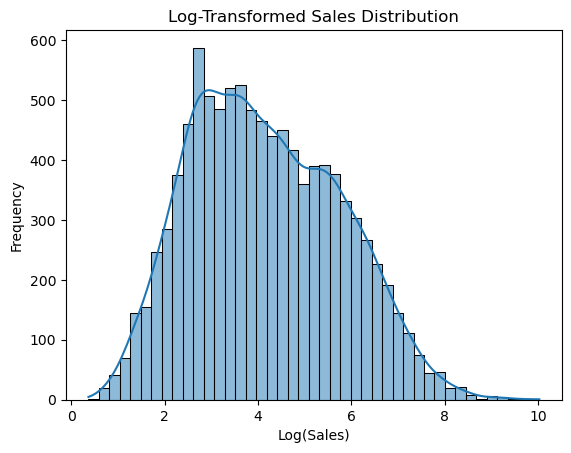

In [37]:
sns.histplot(np.log1p(df['Sales']), kde=True)
plt.title('Log-Transformed Sales Distribution')
plt.xlabel('Log(Sales)')
plt.ylabel('Frequency')
plt.show()

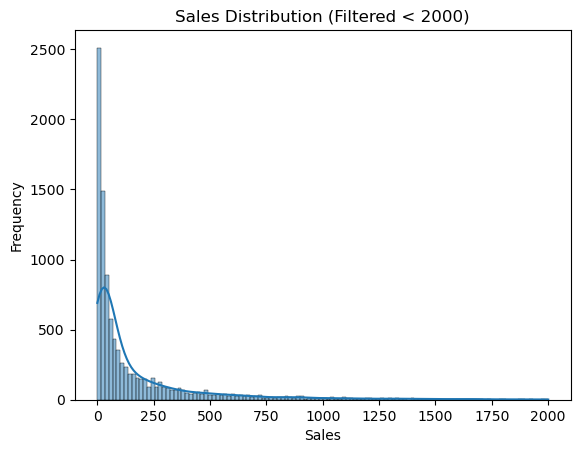

In [38]:
sns.histplot(df[df['Sales'] < 2000]['Sales'], kde=True)
plt.title('Sales Distribution (Filtered < 2000)')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

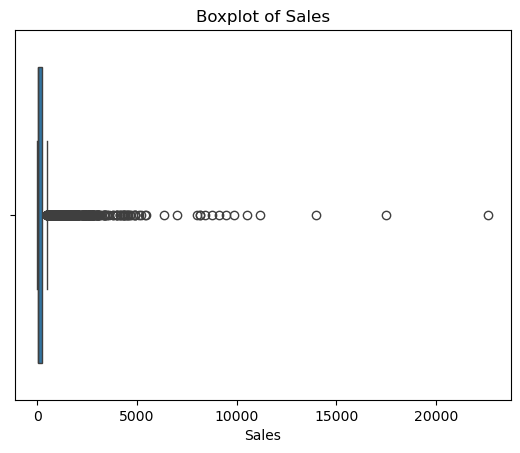

In [39]:
sns.boxplot(x=df['Sales'])
plt.title('Boxplot of Sales')
plt.show()

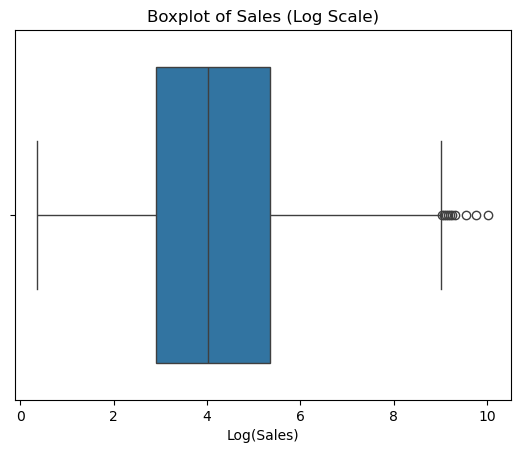

In [40]:
sns.boxplot(x=np.log1p(df['Sales']))
plt.title('Boxplot of Sales (Log Scale)')
plt.xlabel('Log(Sales)')
plt.show()

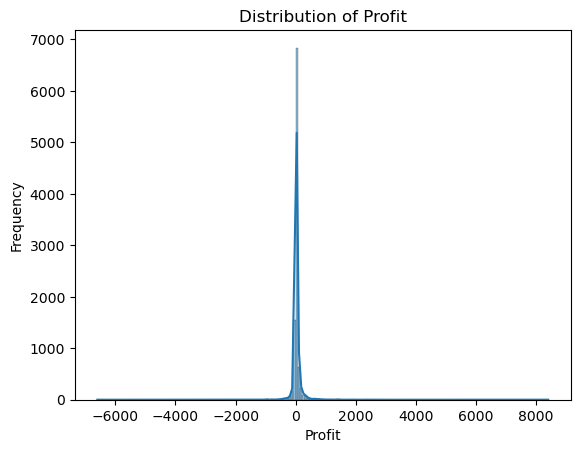

In [41]:
sns.histplot(df['Profit'], kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


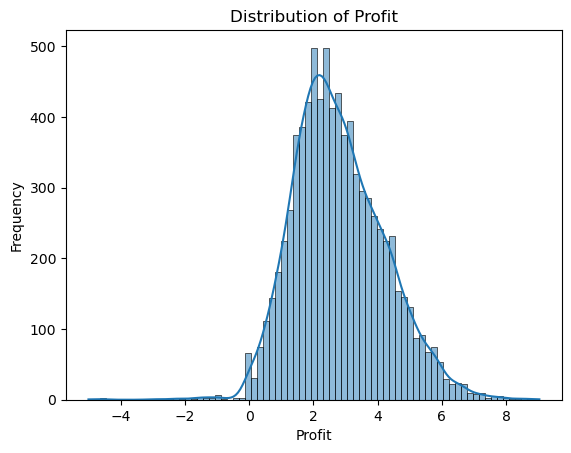

In [42]:
sns.histplot(np.log1p(df['Profit']), kde=True)
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

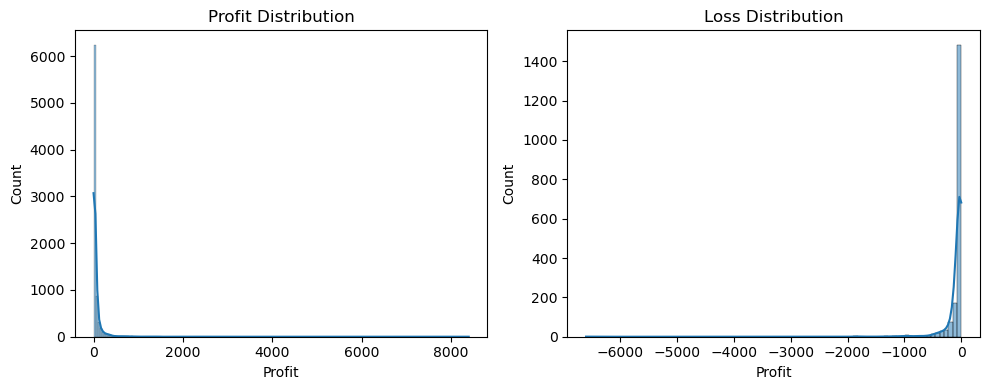

In [43]:
profit_df = df[df['Profit'] > 0]
loss_df = df[df['Profit'] < 0]

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(profit_df['Profit'], kde=True)
plt.title('Profit Distribution')

plt.subplot(1,2,2)
sns.histplot(loss_df['Profit'], kde=True)
plt.title('Loss Distribution')

plt.tight_layout()
plt.show()

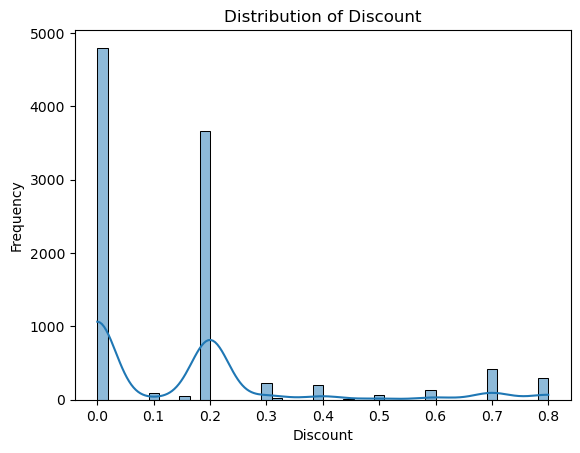

In [44]:
sns.histplot(df['Discount'], kde=True)
plt.title('Distribution of Discount')
plt.xlabel('Discount')
plt.ylabel('Frequency')
plt.show()

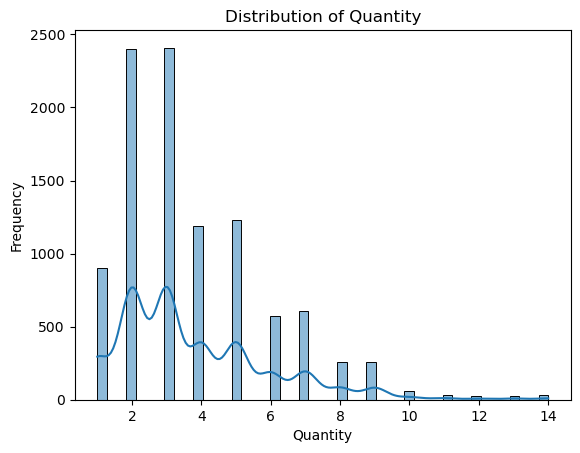

In [45]:
sns.histplot(df['Quantity'], kde=True)
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Frequency')
plt.show()

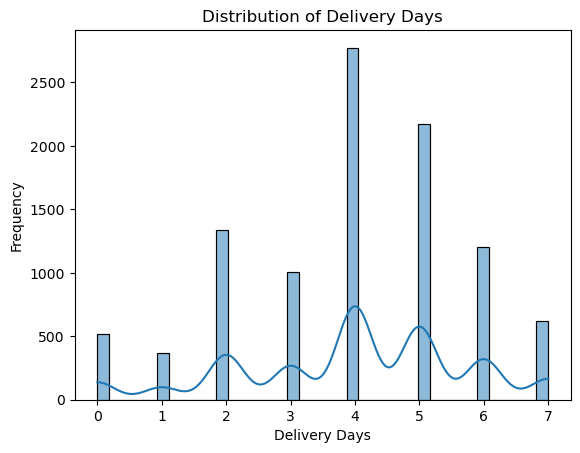

In [46]:
sns.histplot(df['Delivery_days'], kde=True)
plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Frequency')
plt.show()

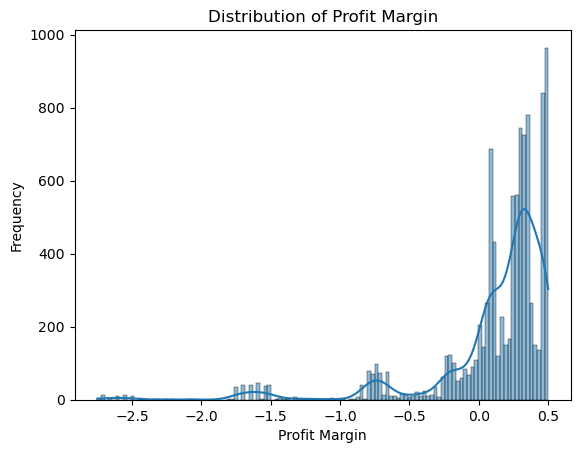

In [47]:
sns.histplot(df['Profit_margin'], kde=True)
plt.title('Distribution of Profit Margin')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.show()

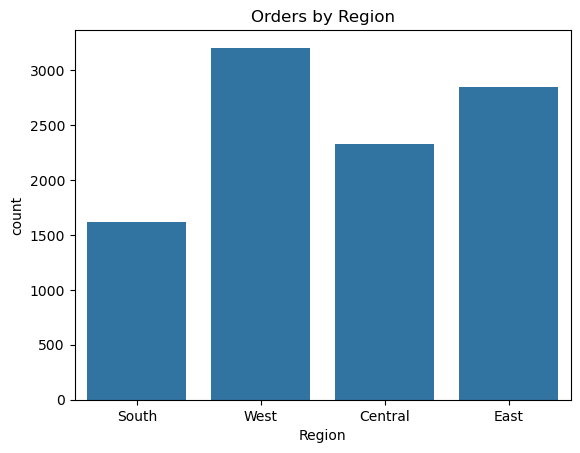

In [48]:
sns.countplot(x='Region', data=df)
plt.title('Orders by Region')
plt.show()

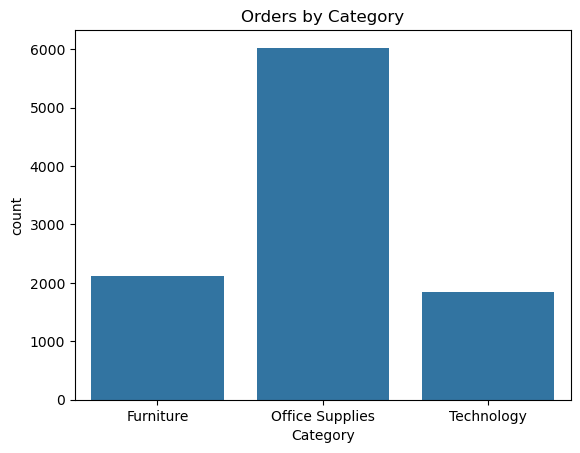

In [49]:
sns.countplot(x='Category', data=df)
plt.title('Orders by Category')
plt.show()

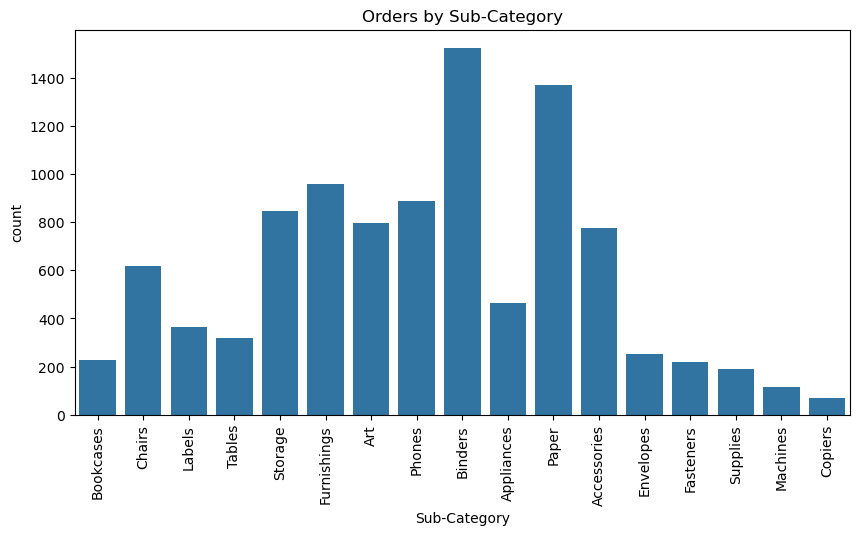

In [50]:
plt.figure(figsize=(10,5))
sns.countplot(x='Sub-Category', data=df)
plt.xticks(rotation=90)
plt.title('Orders by Sub-Category')
plt.show()

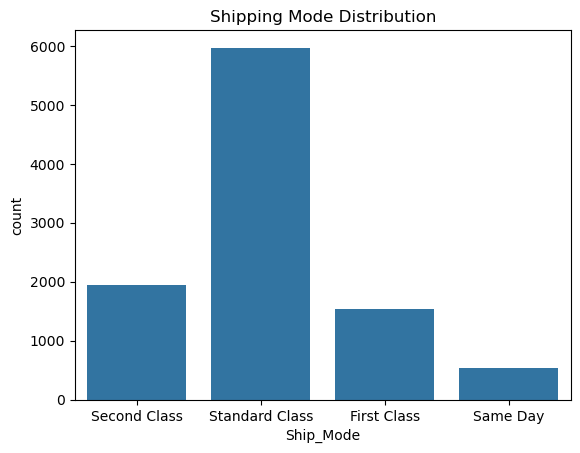

In [51]:
sns.countplot(x='Ship_Mode', data=df)
plt.title('Shipping Mode Distribution')
plt.show()

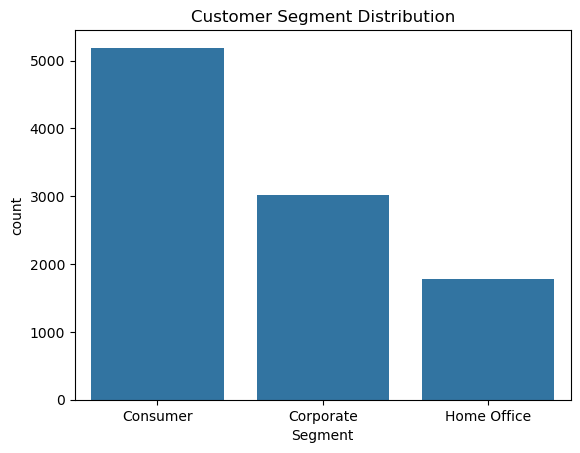

In [52]:
sns.countplot(x='Segment', data=df)
plt.title('Customer Segment Distribution')
plt.show()

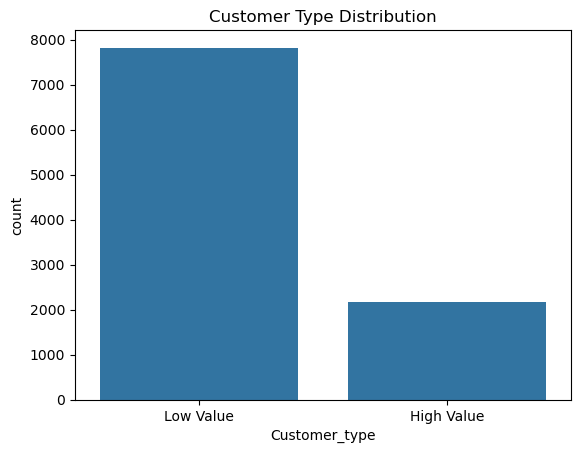

In [53]:
sns.countplot(x='Customer_type', data=df)
plt.title('Customer Type Distribution')
plt.show()

### Bivariate

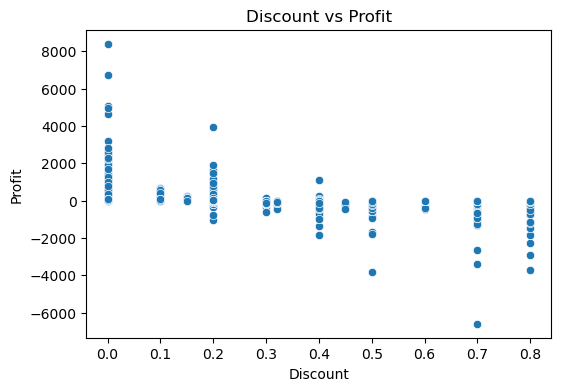

In [54]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount', y='Profit', data=df)
plt.title('Discount vs Profit')
plt.show()

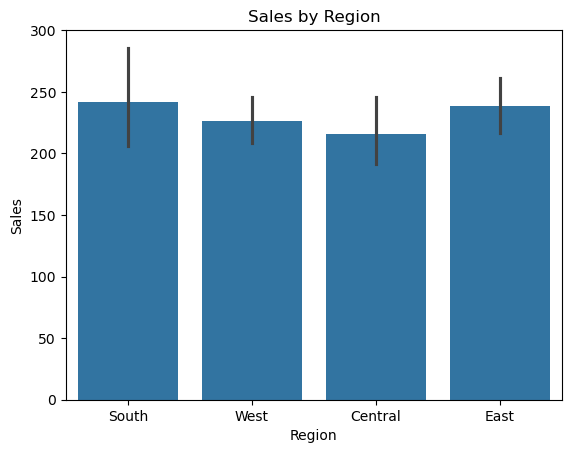

In [55]:
sns.barplot(x='Region', y='Sales', data=df)
plt.title('Sales by Region')
plt.show()

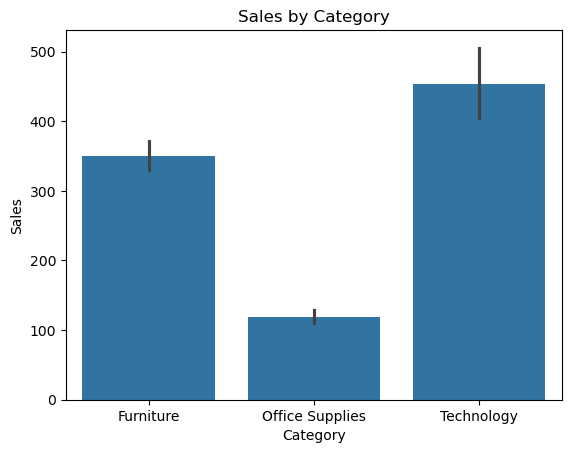

In [56]:
sns.barplot(x='Category', y='Sales', data=df)
plt.title('Sales by Category')
plt.show()

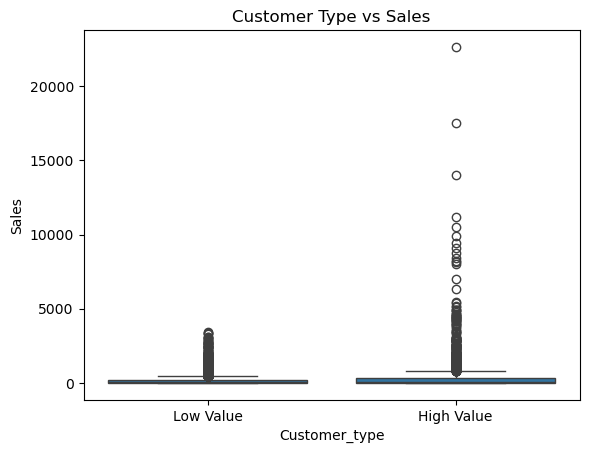

In [57]:
sns.boxplot(x='Customer_type', y='Sales', data=df)
plt.title('Customer Type vs Sales')
plt.show()

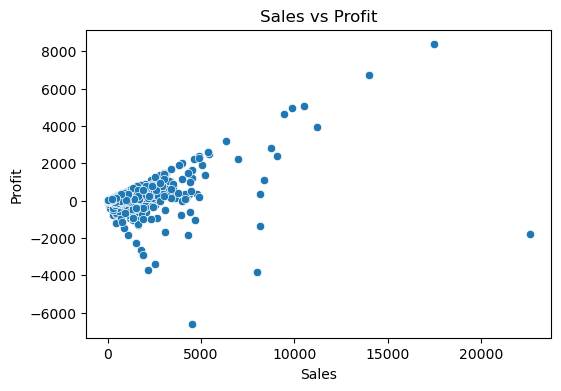

In [58]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title('Sales vs Profit')
plt.show()

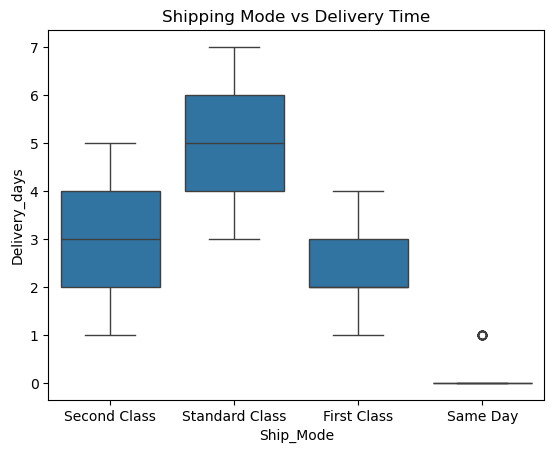

In [59]:
sns.boxplot(x='Ship_Mode', y='Delivery_days', data=df)
plt.title('Shipping Mode vs Delivery Time')
plt.show()

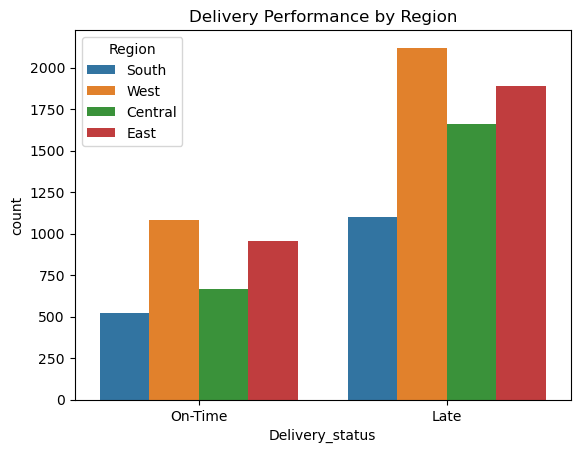

In [60]:
sns.countplot(x='Delivery_status', hue='Region', data=df)
plt.title('Delivery Performance by Region')
plt.show()

 ### Multivariate

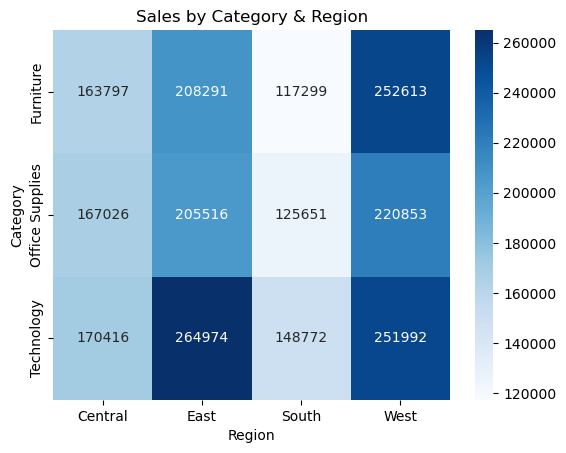

In [61]:
pivot_sales = df.pivot_table(
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum'
)

sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='Blues')
plt.title('Sales by Category & Region')
plt.show()

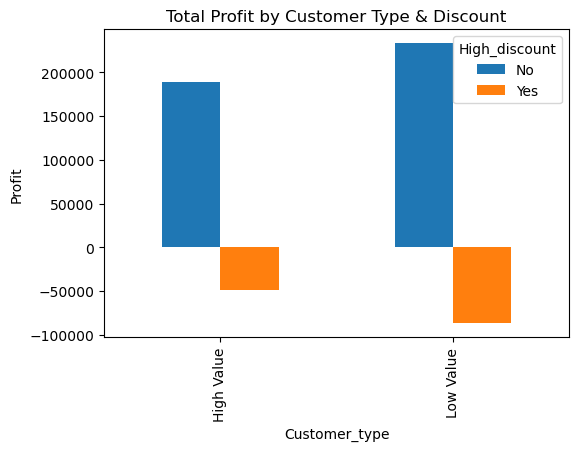

In [62]:
pivot = df.pivot_table(
    values='Profit',
    index='Customer_type',
    columns='High_discount',
    aggfunc='sum'
)

pivot.plot(kind='bar', figsize=(6,4))
plt.title('Total Profit by Customer Type & Discount')
plt.ylabel('Profit')
plt.show()

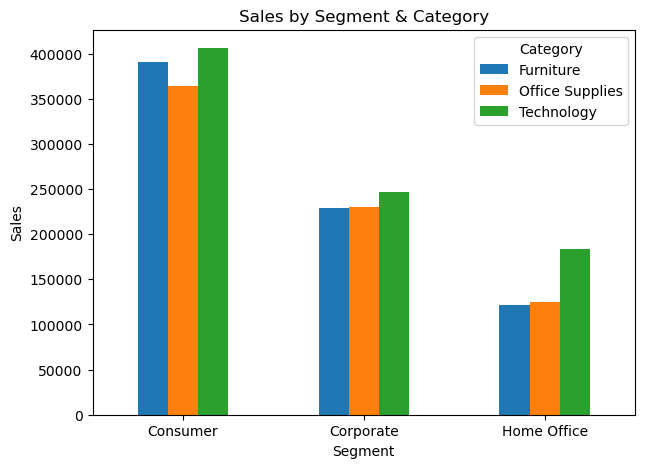

In [63]:
pivot = df.pivot_table(
    values='Sales',
    index='Segment',
    columns='Category',
    aggfunc='sum'
)

pivot.plot(kind='bar', figsize=(7,5))
plt.title('Sales by Segment & Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.show()

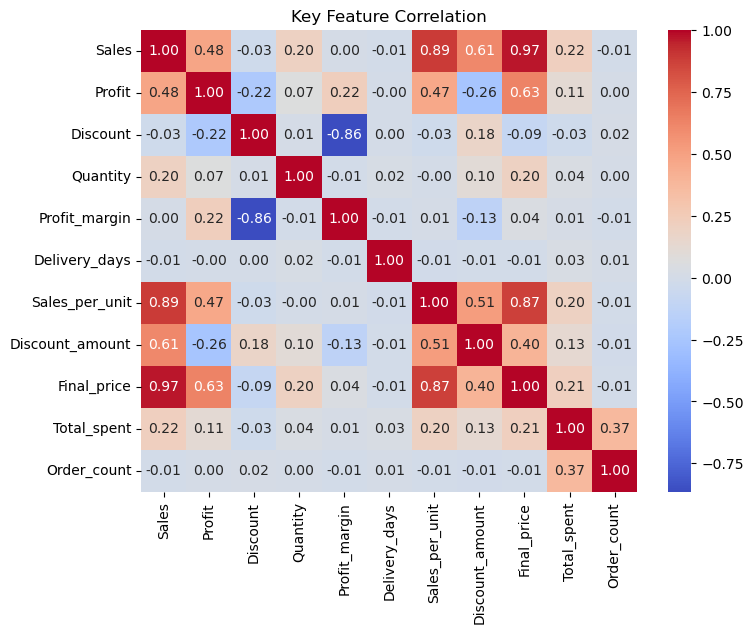

In [64]:
cols = ['Sales', 'Profit', 'Discount', 'Quantity','Profit_margin', 'Delivery_days','Sales_per_unit', 'Discount_amount','Final_price', 'Total_spent', 'Order_count']
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Key Feature Correlation')
plt.show()

In [65]:
df.to_csv('superstore.csv', index=False)

In [66]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Profit_margin', 'Yearr', 'Year', 'Month', 'Quarter', 'Weekday',
       'Delivery_dayss', 'Delivery_days', 'Delivery_status', 'Sales_per_unit',
       'Discount_amount', 'Final_price', 'Total_spent', 'Order_count',
       'Customer_type', 'Order_size', 'Product_performance_flag',
       'High_discount'],
      dtype='object')

In [67]:
customer_df = df[['Customer_ID', 'Customer_Name', 'Segment', 'Customer_type','Order_size' ]].drop_duplicates()

In [68]:
product_df = df[['Product_ID','Product_Name','Category','Sub-Category','Product_performance_flag']].drop_duplicates()

In [69]:
geo_df = df[['Postal_Code','City','State','Region','Country']].drop_duplicates()

In [70]:
delivery_df = df[['Order_ID','Ship_Mode','Delivery_status','Delivery_days']].drop_duplicates()

In [71]:
orders_df = df[['Order_ID','Order_Date','Ship_Date','Customer_ID','Product_ID','Postal_Code','Sales','Quantity','Discount','Profit','Sales_per_unit','Discount_amount','Final_price','High_discount']]

In [72]:
customer_df.to_csv("customer.csv", index=False)
product_df.to_csv("product.csv", index=False)
geo_df.to_csv("geography.csv", index=False)
delivery_df.to_csv("delivery.csv", index=False)
orders_df.to_csv("orders.csv", index=False)